# A reasonable model of dust

Dust maps aren't very accurate as distance increases. Can we do better with a bit of a simple model?

## Imports

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, CartesianRepresentation
from astropy import units as u
from scipy.stats import binned_statistic, expon, powerlaw

from dustmaps.edenhofer2023 import fetch, Edenhofer2023Query


# from pyfftw.interfaces import numpy_fft
from numpy import fft as numpy_fft

In [2]:
# fetch()

In [38]:
dustmap = Edenhofer2023Query(flavor="less_data_but_2kpc")

Optimizing map for querying (this might take a couple of seconds)...


## Plotting Edenhofer+

In [39]:
z_lim = 400
lim = 2000
points = 161
z_points = 31

x_range = np.linspace(-lim, lim, num=points)
y_range = np.linspace(-lim, lim, num=points)
z_range = np.linspace(-z_lim, z_lim, num=z_points)

xx, yy, zz = np.meshgrid(x_range, y_range, z_range)
xx_2d, yy_2d = np.meshgrid(x_range, y_range)

coords = SkyCoord(
    CartesianRepresentation(xx.flatten(), yy.flatten(), zz.flatten(), unit="pc"),
    frame="galactic",
)
coords_2d = SkyCoord(
    CartesianRepresentation(
        xx_2d.flatten(), yy_2d.flatten(), np.zeros(points**2), unit="pc"
    ),
    frame="galactic",
).transform_to("galactocentric")

print(f"Totoal points: {xx.size}")

Totoal points: 803551


In [40]:
extinction_3d = dustmap.query(coords).reshape((points, points, z_points)) * 2.8

# Integrate over z
extinction = np.sum(extinction_3d, axis=2) * (z_range[1] - z_range[0])

# Convert to being per pc in x-y too
# ACTUALLY: isn't necessary, it already is
# extinction = extinction * (x_range[1] - x_range[0])**2

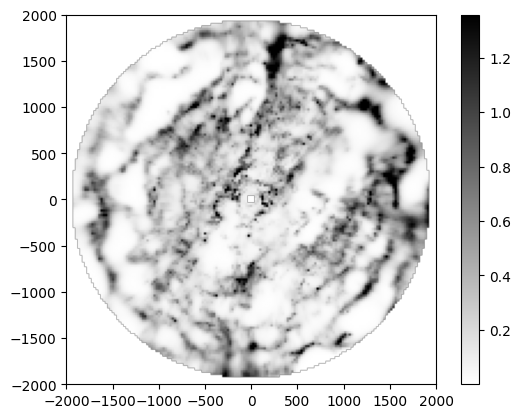

In [41]:
plt.imshow(
    np.clip(extinction, 0, np.quantile(extinction[np.isfinite(extinction)], 0.99)),
    origin="lower",
    extent=(-lim, lim, -lim, lim),
    cmap="gray_r",
)
plt.colorbar()

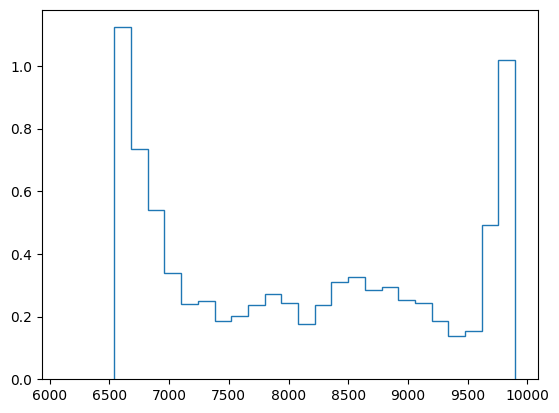

In [42]:
# plt.plot(xx[:, :, 0].flatten(), extinction.flatten(), '.', color="k", alpha=0.05)

r_gc = coords_2d.represent_as("cylindrical").rho.value
values, edges, _ = binned_statistic(r_gc, extinction.flatten(), statistic="median", bins=30)
plt.stairs(values, edges)

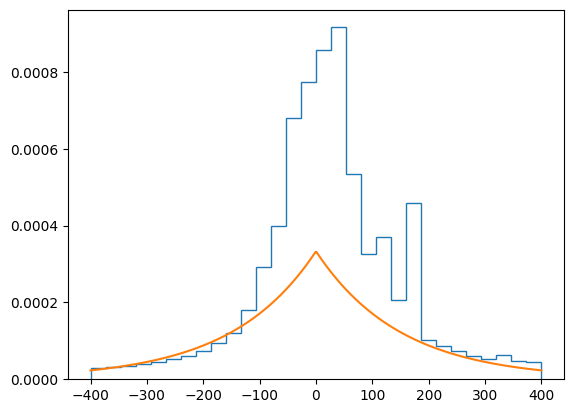

In [43]:
# plt.plot(xx[:, :, 0].flatten(), extinction.flatten(), '.', color="k", alpha=0.05)

z_coords = coords.represent_as("cartesian").z.value
values, edges, _ = binned_statistic(z_coords, extinction_3d.flatten(), statistic="median", bins=30)
plt.stairs(values, edges)

z_range_fine = np.linspace(-z_lim, z_lim, num=500)
z_values = expon(scale=150).pdf(np.abs(z_range_fine))*0.05
plt.plot(z_range_fine, z_values)

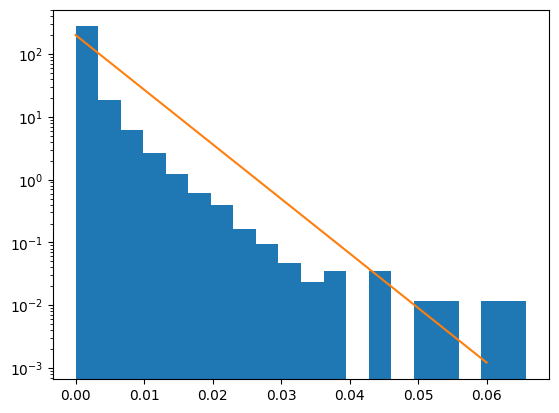

In [9]:
_ = plt.hist(extinction_3d[:, :, z_points // 2].flatten(), bins=20, density=True)
plt.yscale("log")
x_range = np.linspace(0, 0.06)
plt.plot(x_range, expon(scale=5e-3).pdf(x_range))

[None]

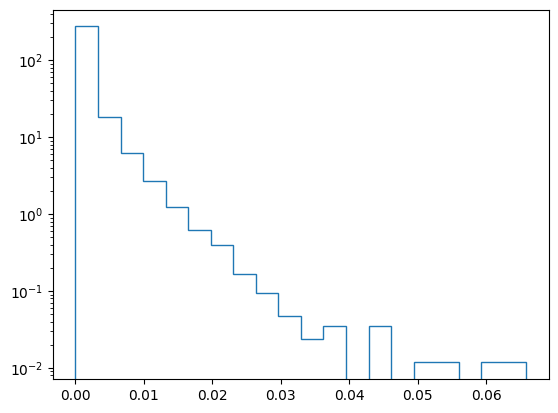

In [10]:
# plt.hist(np.exp(noise.flatten())/700, bins=50, density=True, histtype="step")
_ = plt.hist(extinction_3d[:, :, z_points // 2].flatten(), bins=20, density=True, histtype="step")
plt.gca().set(yscale="log")

## 3D fractal noise map

In [11]:
def fractal_noise_3d(
    extent: tuple[int, int, int],
    shape: tuple[int, int, int],
    correlation_shape: tuple[int, int, int] | None = None,
    seed: int = 42,
    correlation_strength=1,
    scale=1,
    return_coords=False,
):
    """Creates 3d fractal (pink) noise.
    From ocelot & https://stackoverflow.com/a/76605642
    """
    rng = np.random.default_rng(seed)

    if correlation_shape is None:
        correlation_shape = shape

    # Create white noise
    whitenoise = rng.uniform(0, 1, shape)

    # Generate frequency matrix
    ft_arr = np.fft.fftshift(numpy_fft.fftn(whitenoise, correlation_shape))
    x, y, z = [
        np.linspace(-ext * scale, ext * scale, num=num)
        for ext, num in zip(extent, correlation_shape)
    ]
    _x, _y, _z = np.meshgrid(x, y, z)

    f = np.sqrt((_x) ** 2 + (_y) ** 2 + (_z) ** 2) ** correlation_strength

    # Convert to fractal noise
    fractal_fourier_transform = np.zeros_like(ft_arr)
    nonzero_denominator = (f != 0).nonzero()
    fractal_fourier_transform[nonzero_denominator] = (
        ft_arr[nonzero_denominator] / f[nonzero_denominator]
    )
    # fractal_fourier_transform = (
    #     ft_arr / f
    # )
    fractal_noise = numpy_fft.ifftn(
        np.fft.ifftshift(fractal_fourier_transform), shape
    ).real

    # Rescale to have unit variance
    fractal_noise = (fractal_noise - np.mean(fractal_noise)) / np.std(fractal_noise)

    if not return_coords:
        return fractal_noise
    
    x, y, z = [
        np.linspace(-ext, ext, num=num)
        for ext, num in zip(extent, shape)
    ]
    _x, _y, _z = np.meshgrid(x, y, z)
    return fractal_noise, (_x, _y, _z)

In [12]:
noise = fractal_noise_3d((10000, 10000, 100), (500, 500, 25), (500, 500, 25), seed=42)

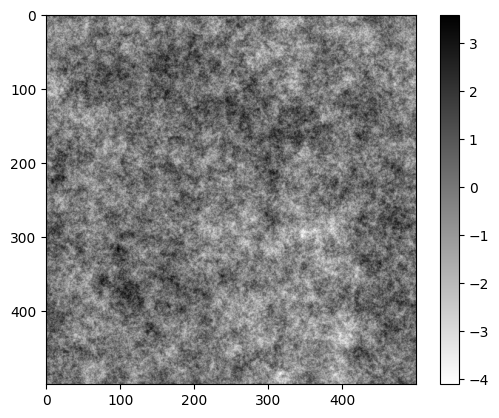

In [13]:
plt.imshow(noise[:, :, 20], cmap="gray_r")
plt.colorbar()

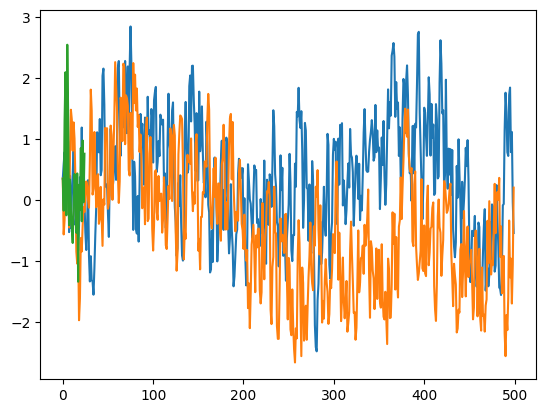

In [14]:
plt.plot(noise[:, 0, 0])
plt.plot(noise[0, :, 0])
plt.plot(noise[0, 0, :])

## Making a MW mock-up

In [23]:
noise, grid = fractal_noise_3d(
    (-20000, 20000, 1000),
    (1000, 1000, 50),
    # (500, 500, 25),
    correlation_strength=1,
    return_coords=True,
)

radius = np.sqrt(grid[0] ** 2 + grid[1] ** 2)

noise_extinction = np.exp(noise)

In [24]:
noise_model = noise_extinction * expon(scale=3000).pdf(radius)

edenhofer_solar_neighbourhood_a_v_per_pc_2d = 0.2

in_box = np.logical_and.reduce(
    (grid[0] > -9100, grid[0] < -7100, grid[1] > -1000, grid[1] < 1000)
)
noise_model_scaled = (
    noise_model
    * edenhofer_solar_neighbourhood_a_v_per_pc_2d
    / np.sum(noise_model[in_box].reshape([in_box.sum(axis=2).max()] * 3), axis=-1).mean()
)

In [25]:
np.sum(noise_model[in_box].reshape([in_box.sum(axis=2).max()] * 3), axis=-1).mean()

np.float64(0.001596531225885444)

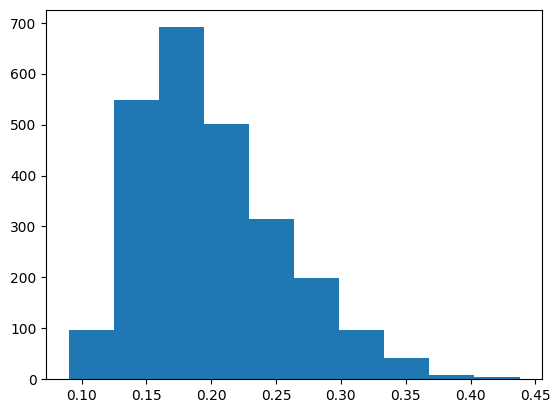

In [26]:
_ = plt.hist(np.sum(noise_model_scaled[in_box].reshape(50, 50, 50), axis=-1).flatten())

In [29]:
np.percentile(noise_model_scaled, 99)

np.float64(0.03737345145305559)

(-1000.0, 1000.0)

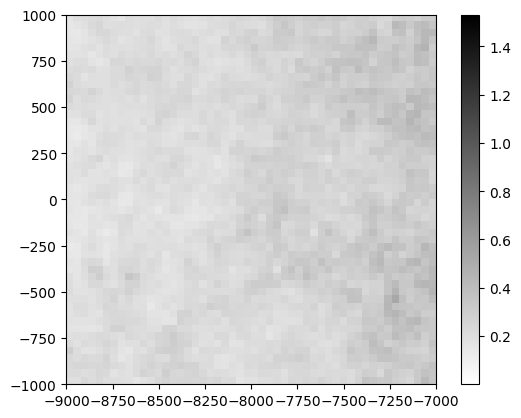

In [37]:
summed = np.sum(noise_model_scaled, axis=-1)

plt.imshow(
    # noise_model[:, :, 12],
    summed,
    cmap="gray_r",
    # norm="log",
    origin="lower",
    vmax=np.percentile(summed, 99),
    extent=(-20000, 20000, -20000, 20000),
)
plt.colorbar()
plt.xlim(-9000, -7000)
plt.ylim(-1000, 1000)

ok that actually looks quite close lol!

[None]

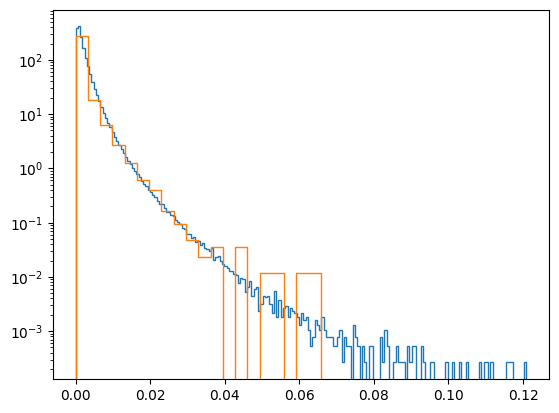

In [ ]:
plt.hist(np.exp(noise.flatten())/800, bins=200, density=True, histtype="step")
_ = plt.hist(extinction_3d[:, :, z_points // 2].flatten(), bins=20, density=True, histtype="step")
plt.gca().set(yscale="log")